# Machine learning model to financial predictions

In [275]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [276]:
notebook_dir = Path().resolve()

# Data folder
data_folder = notebook_dir.parent / "Data"
data_folder.mkdir(exist_ok=True)  # ensures folder exists

In [277]:
quarterly_data_path = data_folder / "quarterly_data.csv"
df = pd.read_csv(quarterly_data_path)

df.shape

(5078, 100)

In [278]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [279]:
# tickers, min-max date, count of daily observations
df.groupby(['ticker'])['date'].agg(['min','max','count'])

,min,max,count
ticker,,,
6501.T,2001-12-31,2025-09-30,96
6758.T,2001-12-31,2025-09-30,96
6861.T,2002-12-31,2025-09-30,92
7203.T,2001-12-31,2025-09-30,96
7267.T,2001-12-31,2025-09-30,96
9432.T,2001-12-31,2025-09-30,96
9984.T,2001-12-31,2025-09-30,96
AAPL,2001-12-31,2025-09-30,96
ABBV,2014-12-31,2025-09-30,44


# 1. Feature engineering

In [280]:
for i, col in enumerate(df.columns, start=1):
    print(i, col)


1 ticker
2 date
3 year
4 quarter
5 close
6 return_1q
7 return_2q
8 return_3q
9 vol_3q
10 momentum_3q
11 qma_2
12 qma_4
13 qma_8
14 marketCap
15 beta
16 trailingPE
17 forwardPE
18 trailing_PEG
19 priceToBook
20 dividendYield
21 debt_to_equity
22 current_ratio
23 cash_ratio
24 working_capital
25 working_capital_ratio
26 retained_earnings_to_assets
27 long_term_debt_to_equity
28 operating_cf_margin
29 free_cf_margin
30 pct_held_by_inst
31 institutional_holders_count
32 esg_env
33 esg_soc
34 esg_gov
35 recent_rating_changes
36 strong_to_total_reco_ratio
37 days_to_next_earnings
38 dividend_stability
39 companyName
40 sector
41 fullTimeEmployees
42 region
43 gdp_us
44 gdp_us_yoy
45 gdp_us_qoq
46 cpi_us
47 cpi_us_yoy
48 cpi_us_qoq
49 unemployment_us
50 unemployment_us_yoy
51 unemployment_us_qoq
52 interest_us
53 interest_us_yoy
54 interest_us_qoq
55 gdp_de
56 gdp_de_yoy
57 gdp_de_qoq
58 cpi_de
59 cpi_de_yoy
60 cpi_de_qoq
61 interest_eu
62 interest_eu_yoy
63 interest_eu_qoq
64 sp500
65 sp500_

In [281]:
df['buy_signal'].value_counts()

buy_signal
True     3020
False    2058
Name: count, dtype: int64

In [282]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078 entries, 0 to 5077
Data columns (total 100 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ticker                       5078 non-null   object        
 1   date                         5078 non-null   datetime64[ns]
 2   year                         5078 non-null   int64         
 3   quarter                      5078 non-null   int64         
 4   close                        5078 non-null   float64       
 5   return_1q                    5078 non-null   float64       
 6   return_2q                    5078 non-null   float64       
 7   return_3q                    5078 non-null   float64       
 8   vol_3q                       5078 non-null   float64       
 9   momentum_3q                  5078 non-null   float64       
 10  qma_2                        5078 non-null   float64       
 11  qma_4                        5078 non-null

In [283]:
df.select_dtypes(include='int64').columns

Index(['year', 'quarter', 'marketCap', 'institutional_holders_count',
       'recent_rating_changes', 'days_to_next_earnings', 'fullTimeEmployees'],
      dtype='object')

In [284]:
CATEGORICAL = ['ticker', 'sector', 'region']

TO_PREDICT = ['buy_signal']

USED_BUY_SIGNAL_LABEL = ['qma_2', 'qma_4', 'return_2q', 'sp500_qoq','momentum_3q', 'trailingPE', 'interest_us_qoq']

TO_DROP = ['companyName', 'date', 'year', 'quarter', 'close'] + USED_BUY_SIGNAL_LABEL + CATEGORICAL

In [285]:
for cat in CATEGORICAL:
    print(df[cat].value_counts())
    print('\n')

ticker
AAPL       96
CVX        96
GE         96
MMM        96
SAP.DE     96
IFX.DE     96
FME.DE     96
BAS.DE     96
BAYN.DE    96
SIE.DE     96
ALV.DE     96
DBK.DE     96
HSBA.L     96
BP.L       96
ULVR.L     96
OR.PA      96
ASML.AS    96
NOVN.SW    96
ROG.SW     96
UBSG.SW    96
7203.T     96
6758.T     96
9432.T     96
9984.T     96
7267.T     96
MSFT       96
CAT        96
XOM        96
UNH        96
NVDA       96
ORCL       96
IBM        96
AMZN       96
CSCO       96
INTU       96
JNJ        96
PFE        96
MS         96
MRK        96
LLY        96
AMGN       96
BMY        96
KO         96
PG         96
PEP        96
JPM        96
BAC        96
GS         96
6501.T     96
6861.T     92
AIR.PA     90
GOOGL      78
META       47
ABBV       44
SHL.DE     23
Name: count, dtype: int64


sector
Technology                1148
Healthcare                1123
Financial Services         768
Industrials                570
Consumer Defensive         480
Communication Services     317
Co

### 1.1 Generate dummy variables for categorical features

In [286]:
dummy_variables = pd.get_dummies(df[CATEGORICAL], dtype='int32')

In [287]:
dummy_variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078 entries, 0 to 5077
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   ticker_6501.T                  5078 non-null   int32
 1   ticker_6758.T                  5078 non-null   int32
 2   ticker_6861.T                  5078 non-null   int32
 3   ticker_7203.T                  5078 non-null   int32
 4   ticker_7267.T                  5078 non-null   int32
 5   ticker_9432.T                  5078 non-null   int32
 6   ticker_9984.T                  5078 non-null   int32
 7   ticker_AAPL                    5078 non-null   int32
 8   ticker_ABBV                    5078 non-null   int32
 9   ticker_AIR.PA                  5078 non-null   int32
 10  ticker_ALV.DE                  5078 non-null   int32
 11  ticker_AMGN                    5078 non-null   int32
 12  ticker_AMZN                    5078 non-null   int32
 13  ticker_ASML.AS    

In [288]:
# Concatenate the dummy variables with the original DataFrame
df_with_dummies = pd.concat([df, dummy_variables], axis=1)

### 1.2 Correlation analysis

In [289]:
df_with_dummies.drop(columns = TO_DROP).corr()[TO_PREDICT].sort_values(by=TO_PREDICT, ascending=False)

,buy_signal
buy_signal,1.000000
return_3q,0.602083
spy_yoy,0.325231
efa_yoy,0.324974
sp500_yoy,0.323944
...,...
usdx_yoy,-0.079917
vol_3q,-0.101314
unemployment_us_yoy,-0.158219
vix_yoy,-0.216544


## 2. Random Forest Model

In [290]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [291]:
df_model = df_with_dummies.copy()

In [292]:
# 1. Sort chronologically
df_model = df_model.sort_values(['date', 'ticker']).reset_index(drop=True)

# 2. Automatic 80/20 date cutoff

start_date = df_model['date'].min()
end_date = df_model['date'].max()
cutoff_date = start_date + (end_date - start_date) * 0.8

print(f"Train: {start_date.date()} → {cutoff_date.date()}")
print(f"Test:  {cutoff_date.date()} → {end_date.date()}")



Train: 2001-12-31 → 2020-12-30
Test:  2020-12-30 → 2025-09-30


In [293]:
train_df = df_model[df_model['date'] < cutoff_date]
test_df  = df_model[df_model['date'] >= cutoff_date]

In [294]:
# 3. Features and target
X_train = train_df.drop(CATEGORICAL+TO_PREDICT+TO_DROP, axis=1)
y_train = train_df['buy_signal']

X_test  = test_df.drop(CATEGORICAL+TO_PREDICT+TO_DROP, axis=1)
y_test  = test_df['buy_signal']

In [295]:
# 4. Define model and param grid
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


In [296]:
# 5. TimeSeriesSplit for CV
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.8576168929110105


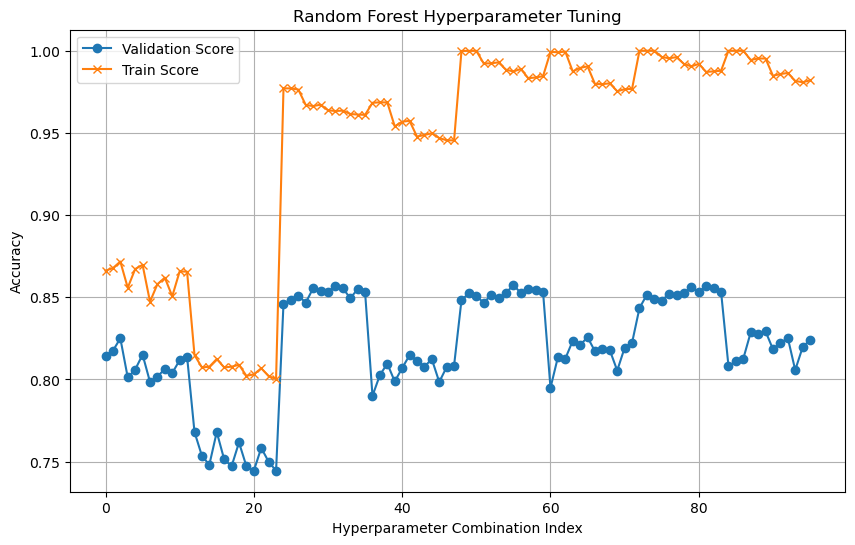

In [297]:
# 6. Visualize hyperparameter tuning results

results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(results['mean_test_score'], label='Validation Score', marker='o')
plt.plot(results['mean_train_score'], label='Train Score', marker='x')
plt.xlabel('Hyperparameter Combination Index')
plt.ylabel('Accuracy')
plt.title('Random Forest Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()



In [298]:
# 7. Train best model and evaluate
# =============================
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Test Accuracy: 0.8872727272727273

Classification Report:
               precision    recall  f1-score   support

       False       0.91      0.78      0.84       413
        True       0.88      0.95      0.91       687

    accuracy                           0.89      1100
   macro avg       0.89      0.87      0.88      1100
weighted avg       0.89      0.89      0.89      1100



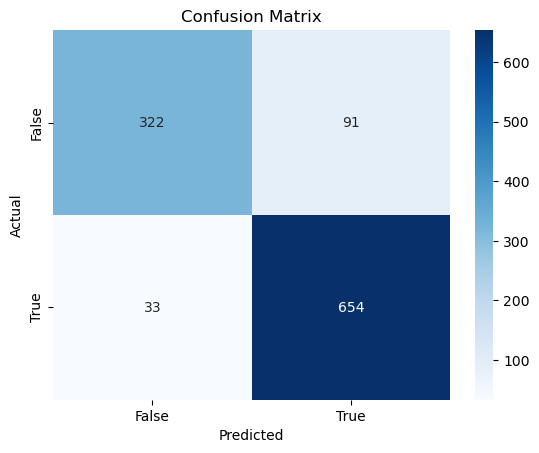

In [299]:
cm = confusion_matrix(y_test, y_pred)

labels = sorted(df['buy_signal'].unique())
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## Model Visuals

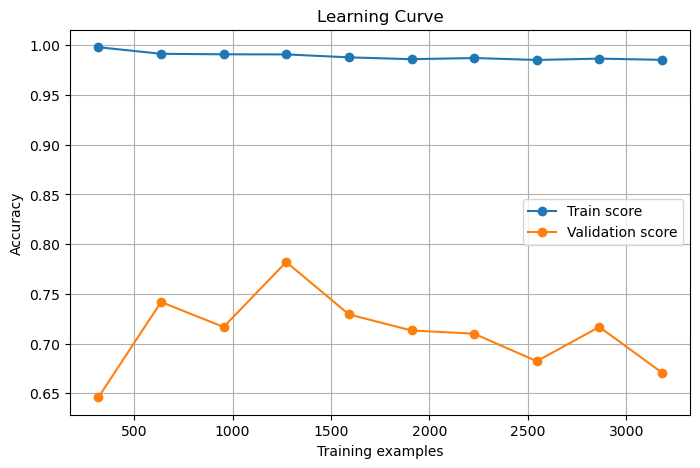

In [300]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    grid_search.best_estimator_,
    X_train, y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation score')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


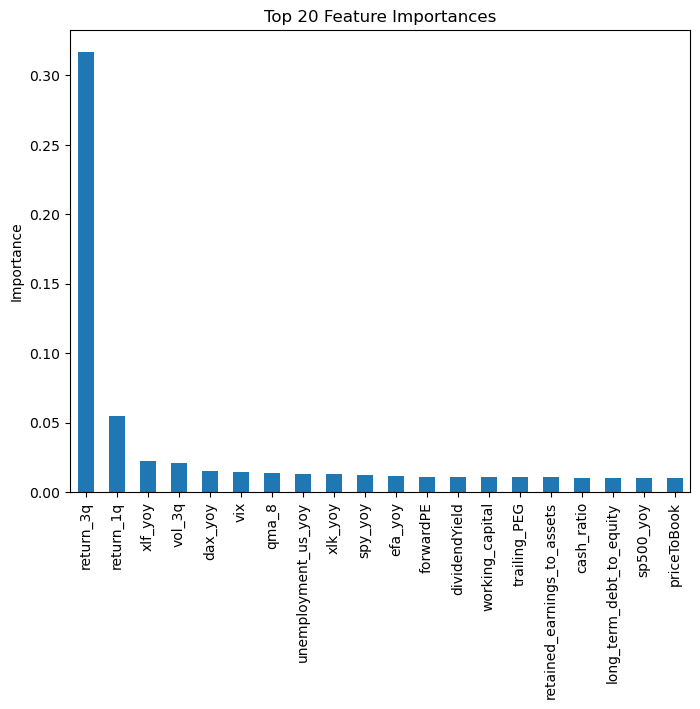

In [301]:
importances = grid_search.best_estimator_.feature_importances_
features = X_train.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='bar')
plt.title('Top 20 Feature Importances')
plt.ylabel('Importance')
plt.show()

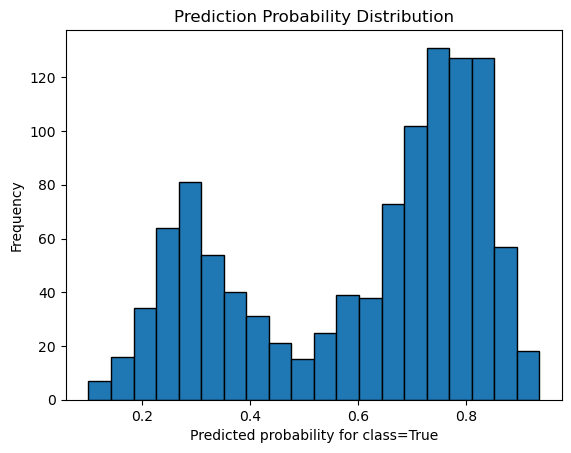

In [302]:
probs = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
plt.hist(probs, bins=20, edgecolor='k')
plt.xlabel('Predicted probability for class=True')
plt.ylabel('Frequency')
plt.title('Prediction Probability Distribution')
plt.show()